In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,f1_score
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

In [2]:
data = pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")
X = data.drop("Churn",axis=1)
y = data["Churn"]




# **Exploratory Data Analysis**

In [3]:
# Printing top '5' rows of the data
data.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Printing bottom '5' rows of the data
data.tail(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [5]:
# Checking more information about data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# Checking for unique values in data
data.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [7]:
# Statistical Summary
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
# Checking for duplicate and null values
print(f"Number of duplicate rows:- {data.duplicated().sum()}\n")

data.isnull().sum().rename("Null Counts")

Number of duplicate rows:- 0



customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
Name: Null Counts, dtype: int64

In [9]:
# Data Type Count
str_data = data.select_dtypes('object')
numerical_data = data.select_dtypes(['int64','float64','int','float'])

print(f"There are {str_data.columns.size} rows with string data type.\n")
for column in str_data.columns:
    print(column)

There are 18 rows with string data type.

customerID
gender
Partner
Dependents
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
TotalCharges
Churn


**`Total Charge` is listed as string data type, however according to the data it should have been a numeric data type. It will be converted to a numeric data type**

In [10]:
# Numeric data type
print(f"There are {numerical_data.columns.size} rows with numeric data type.\n")
for column in numerical_data.columns:
    print(column)

There are 3 rows with numeric data type.

SeniorCitizen
tenure
MonthlyCharges


In [11]:
# Converting TotalCharges to Numeric dtype
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"],errors='coerce')
X["TotalCharges"] = pd.to_numeric(X["TotalCharges"],errors='coerce')
# Checking for null values
print(data["TotalCharges"].isnull().sum(), "null values")

11 null values


**After converting to numeric dtype, the column has some missing values.There must be some invalid values that python cannot convert into float type, causing them to be NaN.**

In [12]:
# Checking for categorical data
categorical = X.columns[(X.nunique() >= 2) & (X.nunique() < 10)]
# Splitting into three parts
categorical1 = categorical[0:6]
categorical2 = categorical[6:12]
categorical3 = categorical[12:17]

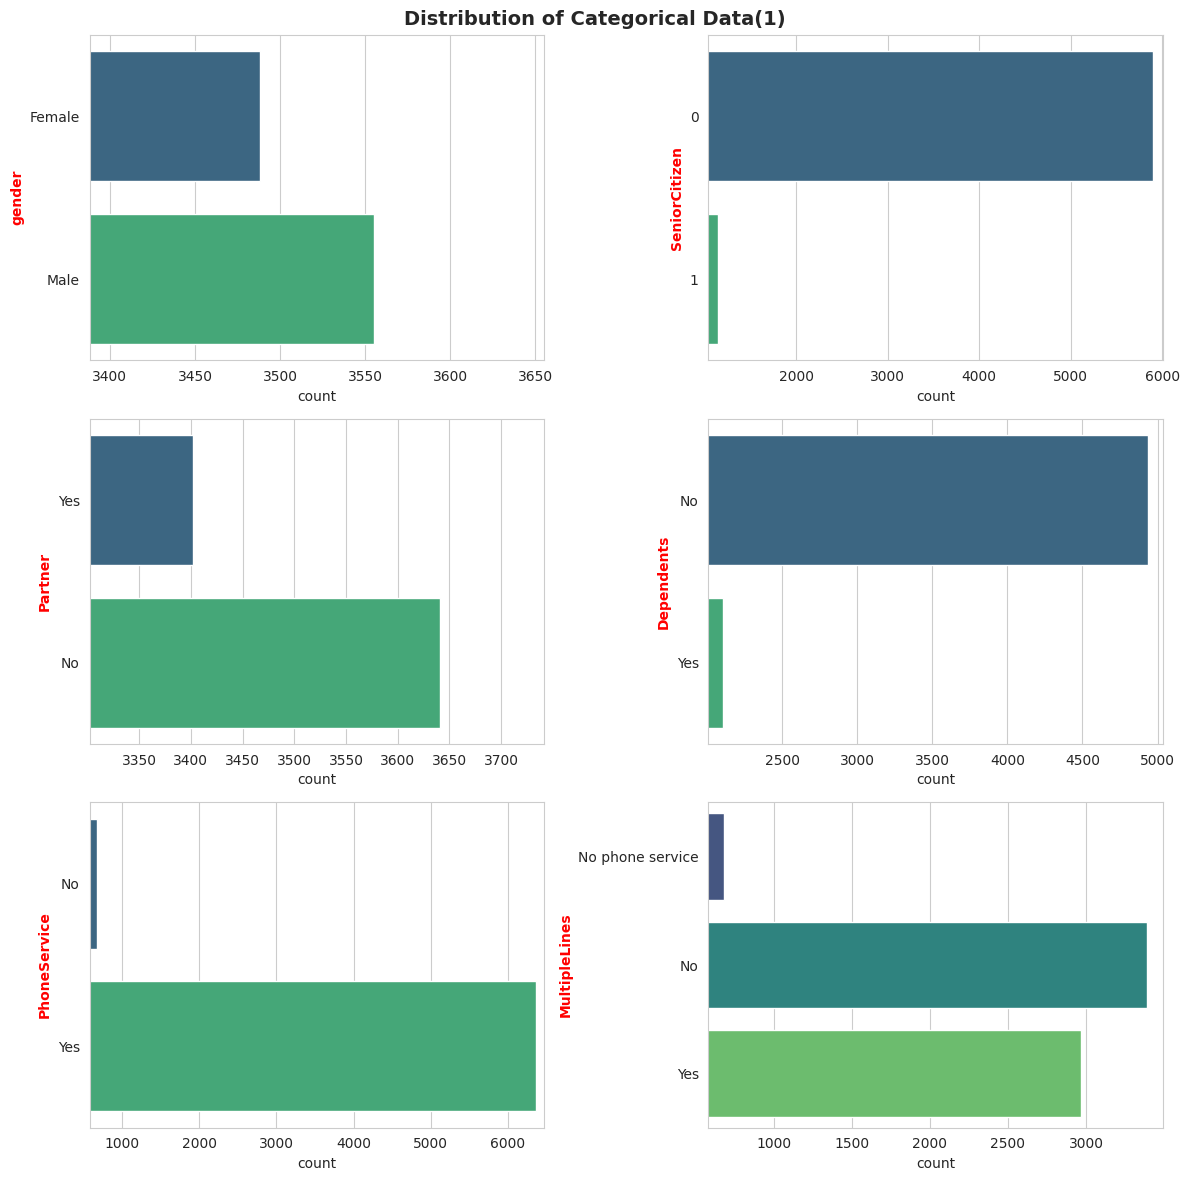

In [13]:
# Plotting categorical1 data
fig, axes = plt.subplots(3,2,figsize=(12,12))
for idx, category in enumerate(categorical1):
    row = idx // 2
    column = idx % 2
    min = data[category].value_counts().min() - 100
    max = data[category].value_counts().max() + 100
    
    sns.countplot(data=data,y=category,ax=axes[row,column],palette='viridis')
    axes[row,column].set_ylabel(category,weight="bold",color="red")
    axes[row,column].set_xlim(min,max)

plt.suptitle("Distribution of Categorical Data(1)",weight="bold",fontsize=14)
plt.tight_layout()
plt.show()




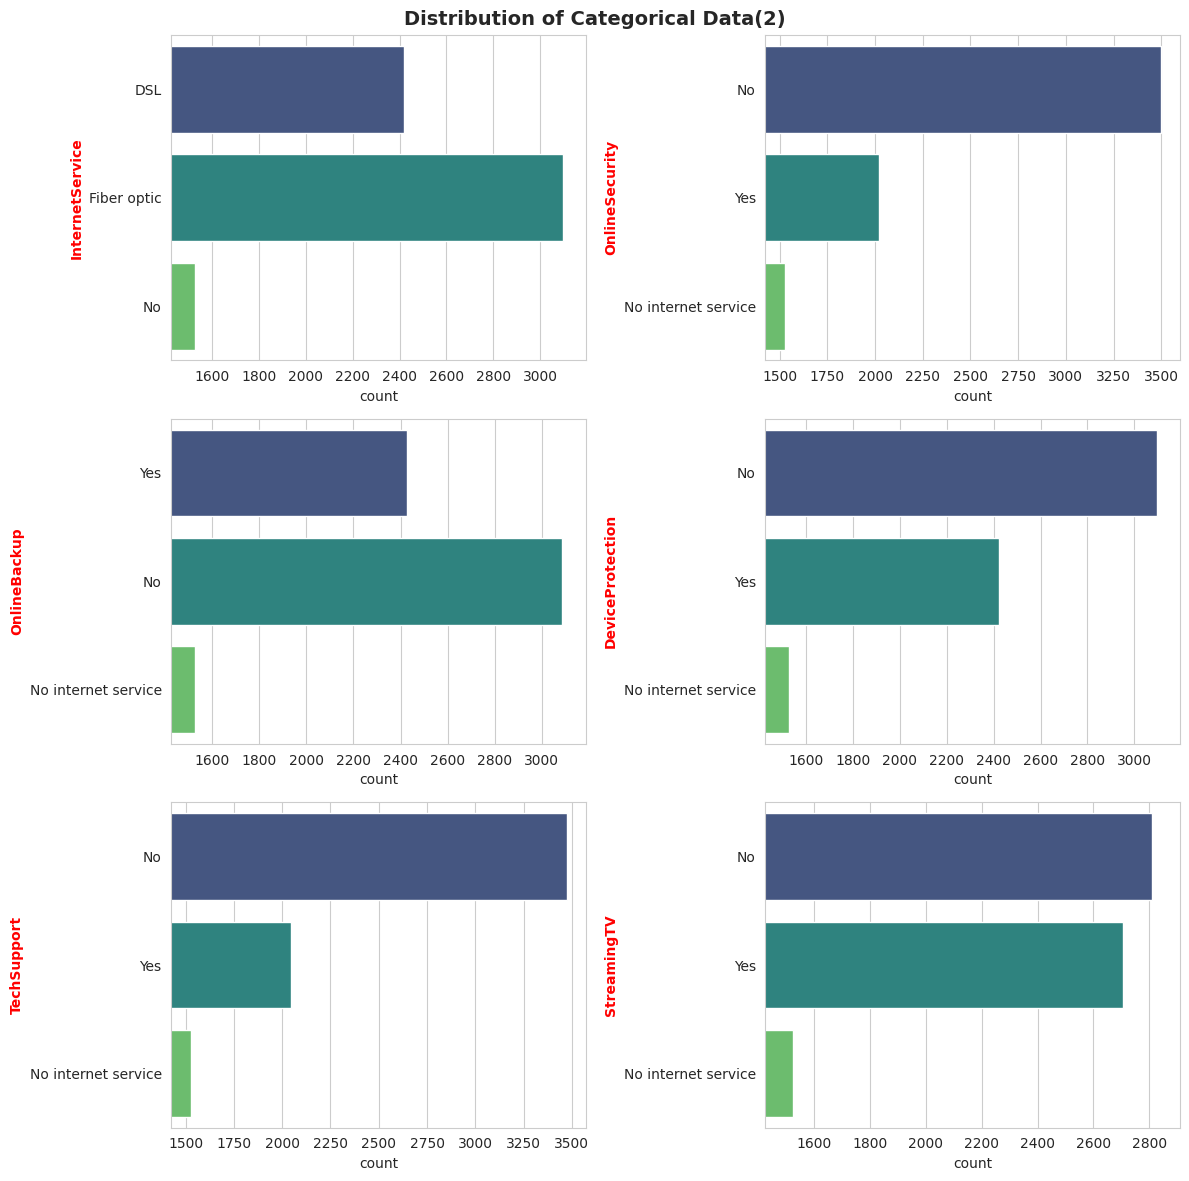

In [14]:
# Plotting categorical2 data
fig, axes = plt.subplots(3,2,figsize=(12,12))
for idx, category in enumerate(categorical2):
    row = idx // 2
    column = idx % 2
    min = data[category].value_counts().min() - 100
    max = data[category].value_counts().max() + 100
    
    sns.countplot(data=data,y=category,ax=axes[row,column],palette='viridis')
    axes[row,column].set_ylabel(category,weight="bold",color="red")
    axes[row,column].set_xlim(min,max)

plt.suptitle("Distribution of Categorical Data(2)",weight="bold",fontsize=14)
plt.tight_layout()
plt.show()


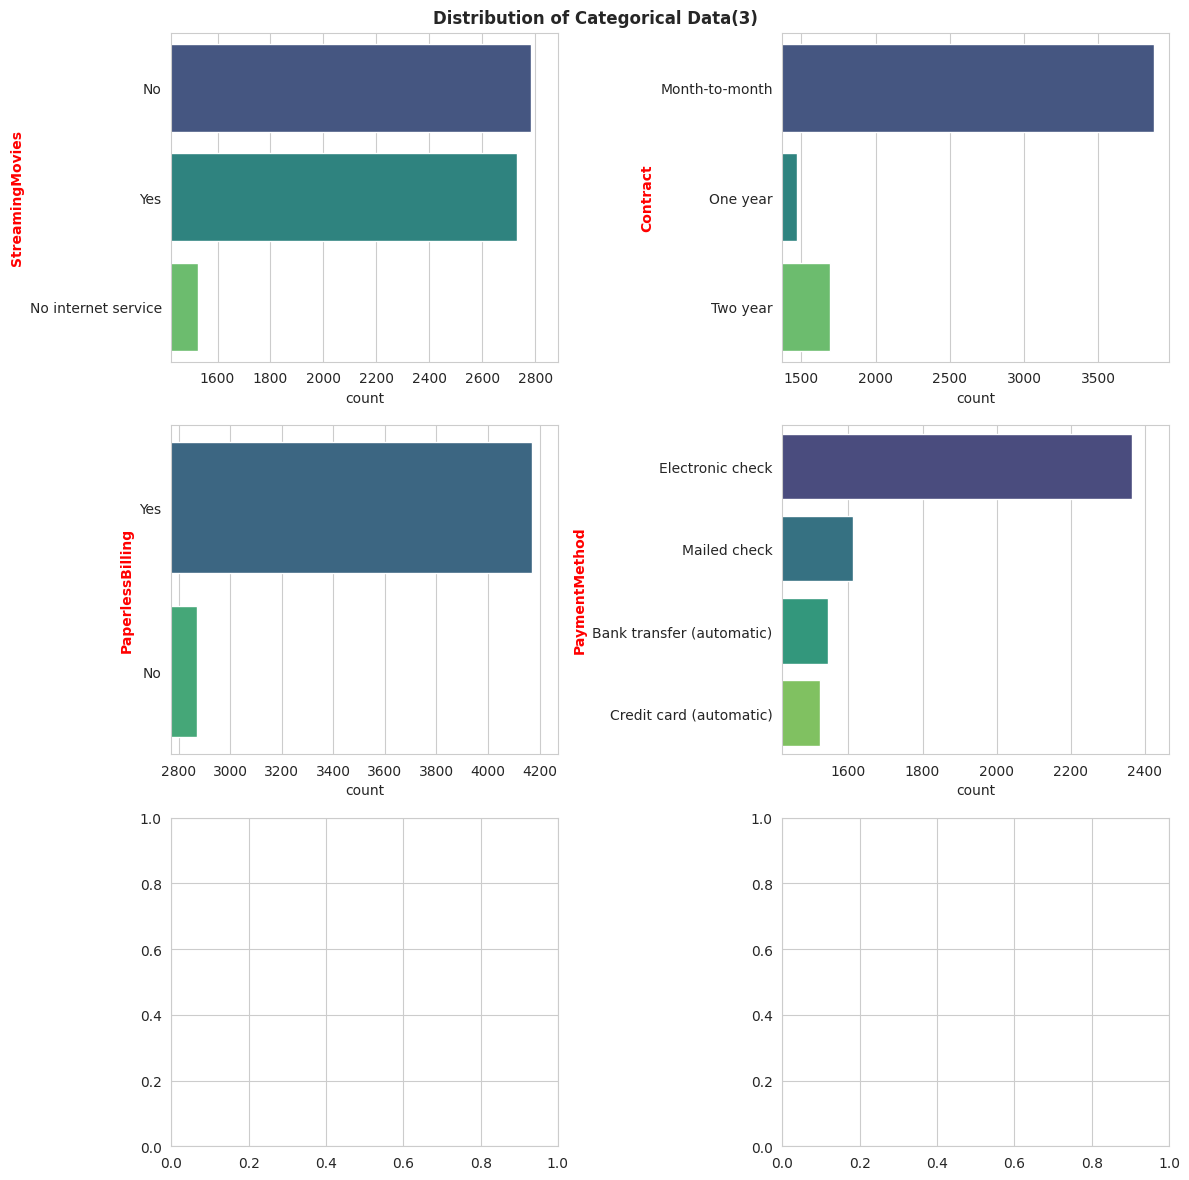

In [15]:
# Plotting categorical3 data
fig, axes = plt.subplots(3,2,figsize=(12,12))
for idx, category in enumerate(categorical3):
    row = idx // 2
    column = idx % 2
    min = data[category].value_counts().min() - 100
    max = data[category].value_counts().max() + 100
    
    sns.countplot(data=data,y=category,ax=axes[row,column],palette='viridis')
    axes[row,column].set_ylabel(category,weight="bold",color="red")
    axes[row,column].set_xlim(min,max)


plt.suptitle("Distribution of Categorical Data(3)",weight="bold")
plt.tight_layout()
plt.show()

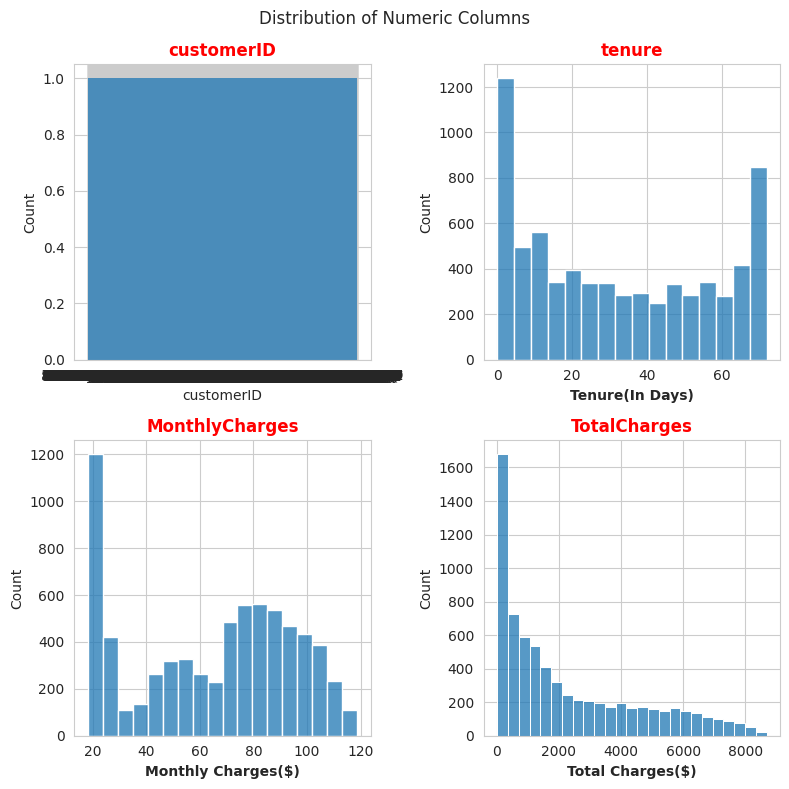

In [16]:
# Plotting numerical data
numeric = [column for column in X.columns if column not in categorical]

# Creating a subplot of 2x2
fig, axes = plt.subplots(2,2,figsize=(8,8))

for idx, columns in enumerate(numeric):
    row = idx // 2
    column = idx % 2

    sns.histplot(data=X,x=columns,ax=axes[row,column])
    axes[row,column].set_title(columns,weight="bold",color="red")

plt.suptitle("Distribution of Numeric Columns")
axes[0,1].set_xlabel('Tenure(In Days)',weight="bold")
axes[1,0].set_xlabel('Monthly Charges($)',weight="bold")
axes[1,1].set_xlabel('Total Charges($)',weight="bold")
plt.tight_layout()
plt.show()

Monthly Charges are fairly balanced and assymetric. However, total charges seem to have a downwards trend, where as charges go up the count goes down. That means higher charges are rarer.

# Preprocessing Pipeline
##### Ordinal Feature --> Ordinal encoding
##### Nominal Feature --> One-Hot Encoding
##### TotalCharges --> SimpleImputer


In [35]:
# Label Encoding 'Churn' column
y = data["Churn"].map({'No': 0, 'Yes': 1})
# Splitting into train and test groups
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
# Importing necessary classes and methods
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer


#Fetching ordinal features
ordinal = [category for category in categorical if X[category].nunique() == 2]
# Fetching nominal features
nominal = [category for category in categorical if category not in ordinal]
preprocessor = ColumnTransformer(transformers=[("ordinal", OrdinalEncoder(), ordinal),
                                              ("nominal", OneHotEncoder(sparse_output=False,handle_unknown="ignore"), nominal),
                                              ("imputer", SimpleImputer(), ['TotalCharges'])],
                                remainder="drop")
preprocessor.set_output(transform="pandas")

ColumnTransformer(transformers=[('ordinal', OrdinalEncoder(),
                                 ['gender', 'SeniorCitizen', 'Partner',
                                  'Dependents', 'PhoneService',
                                  'PaperlessBilling']),
                                ('nominal',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['MultipleLines', 'InternetService',
                                  'OnlineSecurity', 'OnlineBackup',
                                  'DeviceProtection', 'TechSupport',
                                  'StreamingTV', 'StreamingMovies', 'Contract',
                                  'PaymentMethod']),
                                ('imputer', SimpleImputer(), ['TotalCharges'])])

# Feature Selection
#### Using 3 selectors --> Chi2,f_classif,rfecv
#### 3 Models --> LogisticRegression, DecisionTreeClassifier,RandomForestClassifier

In [18]:
# Importing required classes and methods
from sklearn.feature_selection import RFECV,f_classif,chi2,SelectKBest
# Creating a table for recording selected features from each class
features_table = pd.DataFrame(columns=["Selector","Model","selected_features"])

# Creating a function to Select Features
import pandas as pd
from sklearn.feature_selection import RFECV, SelectKBest, chi2, f_classif


from sklearn.base import clone
from sklearn.feature_selection import RFECV, SelectKBest


from sklearn.base import clone
from sklearn.feature_selection import RFECV, SelectKBest


def select_features(X1, y1, selector_type, k=None, estimator=None):
    # 1. Transform features
    X_train_processed = preprocessor.fit_transform(X1)
    feature_names = preprocessor.get_feature_names_out()

    # 2. Get estimator model name safely BEFORE fitting
    model_name = estimator.__class__.__name__ if estimator is not None else "None"

    # 3. Handle RFECV vs SelectKBest
    if selector_type == RFECV or selector_type == "RFECV":
        if estimator is None:
            raise ValueError("RFECV requires an estimator.")

        selector = RFECV(estimator=clone(estimator), step=1, cv=5)
        selector_name = f"RFECV ({model_name})"
    else:
        selector = SelectKBest(score_func=selector_type, k=k)
        selector_name = getattr(selector_type, "__name__", str(selector_type))

    # 4. Fit selector
    selector.fit(X_train_processed, y1)
    selected_features = feature_names[selector.get_support()].tolist()

    # 5. Record results (Use `model_name` string instead of `estimator` object)
    features_table.loc[len(features_table)] = [
        selector_name,
        model_name,  # FIXED: Pass string name directly
        selected_features,
    ]

    return selector.transform(X_train_processed)

### Chi-Squared Test

In [19]:
select_features(X1=X_train,y1=y_train,selector_type=chi2,k=5)

array([[0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.33680e+03],
       [1.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00, 5.12945e+03],
       [1.00000e+00, 1.00000e+00, 0.00000e+00, 1.00000e+00, 2.34500e+01],
       ...,
       [0.00000e+00, 1.00000e+00, 0.00000e+00, 1.00000e+00, 3.06050e+02],
       [1.00000e+00, 1.00000e+00, 0.00000e+00, 1.00000e+00, 1.20015e+03],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 4.57300e+02]])

### ANOVA - F

In [20]:
select_features(X1=X_train,y1=y_train,selector_type=f_classif,k=5)

array([[0., 0., 1., 0., 0.],
       [1., 1., 1., 0., 1.],
       [0., 1., 1., 1., 0.],
       ...,
       [0., 0., 0., 1., 0.],
       [1., 1., 1., 1., 0.],
       [0., 0., 0., 0., 0.]])

In [21]:
features_table

,Selector,Model,selected_features
0,chi2,None,"[nominal__OnlineSecurity_No, nominal__Contract..."
1,f_classif,None,"[nominal__InternetService_Fiber optic, nominal..."


### Recursive Feature Elimination Cross-Validation


In [22]:
#RFECV for Logistic Regression
select_features(X1=X_train,y1=y_train,selector_type=RFECV,k=5,estimator=LogisticRegression())
#RFECV for Decision Tree
select_features(X1=X_train,y1=y_train,selector_type=RFECV,k=5,estimator=DecisionTreeClassifier())
#RFECV for Random Forest
select_features(X1=X_train,y1=y_train,selector_type=RFECV,k=5,estimator=RandomForestClassifier())

array([[0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        0.00000e+00, 1.33680e+03],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        0.00000e+00, 5.12945e+03],
       [1.00000e+00, 0.00000e+00, 1.00000e+00, ..., 0.00000e+00,
        1.00000e+00, 2.34500e+01],
       ...,
       [1.00000e+00, 0.00000e+00, 1.00000e+00, ..., 0.00000e+00,
        1.00000e+00, 3.06050e+02],
       [1.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.00000e+00, 1.20015e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 4.57300e+02]])

In [23]:
features_table

,Selector,Model,selected_features
0,chi2,None,"[nominal__OnlineSecurity_No, nominal__Contract..."
1,f_classif,None,"[nominal__InternetService_Fiber optic, nominal..."
2,RFECV (LogisticRegression),LogisticRegression,"[ordinal__gender, ordinal__SeniorCitizen, ordi..."
3,RFECV (DecisionTreeClassifier),DecisionTreeClassifier,"[ordinal__gender, ordinal__SeniorCitizen, ordi..."
4,RFECV (RandomForestClassifier),RandomForestClassifier,"[ordinal__gender, ordinal__SeniorCitizen, ordi..."


#### Using above selected features, models will be trained and evaluated. 
#### Such trained models would be compared to baseline models without any tuning or selected features.

# Model Comparision

### Baseline models

In [48]:
# Creating a function to train models
models_table = pd.DataFrame(columns=["Model","Type","Accuracy","Precision","F1","CV"])
def train_model(estimator,X1,y1,X1_test,y1_test,type="Baseline",features=None):
    X_processed = preprocessor.fit_transform(X1)
    X_test_processed = preprocessor.transform(X1_test)
    if features == None:
        features = X_processed.columns.to_list()
    model = estimator
    model.fit(X_processed[features],y1)
    y_pred = model.predict(X_test_processed[features])
    accuracy = accuracy_score(y1_test,y_pred)
    precision = precision_score(y1_test,y_pred)
    f1 = f1_score(y1_test,y_pred)
    cv = cross_val_score(model,X_processed,y1,scoring="accuracy",cv=5).mean()
    return [str(estimator).split("(")[0],type,accuracy,precision,f1,cv]

In [46]:
# Baseline Logistic Regression
base_log_reg = LogisticRegression()
models_table.loc[len(models_table)] = train_model(estimator=base_log_reg,X1=X_train,y1=y_train,X1_test=X_test,y1_test=y_test)

# Baseline Decision Tree
base_decision_tree = DecisionTreeClassifier()
models_table.loc[len(models_table)] = train_model(estimator=base_decision_tree,X1=X_train,y1=y_train,X1_test=X_test,y1_test=y_test)

# Baseline Random Forest
base_random_forest = RandomForestClassifier()
models_table.loc[len(models_table)] = train_model(estimator=base_random_forest,X1=X_train,y1=y_train,X1_test=X_test,y1_test=y_test)



### Models After Feature Selection

In [51]:
# Feature selected Logistic Regression
# Chi-Selected Features
chi_selected = features_table.loc["selected_features", features_table["Selector"] == "chi2"]

KeyError: 'Selector'